# 04 — Kanonik Lago LEAR benchmark'ı (gerçek epftoolbox)

**Tarih:** 27 Ağustos 2026 · **Plan:** `LAGO_BENCHMARK_PLAN.md` Faz B

## Ne

`01`/`02`/`03` üç ayrı protokol kullanıyordu. Bu defter **dondurulmuş protokolle**
(`src/eval/lago_protocol.py` sabitleri) gerçek `epftoolbox` LEAR'ını Türkiye GÖP
verisinde koşar ve iki katmanlı raporlar:

- **Uzun pencere** (3 yıl, 2023-08-28 → 2026-08-27): LEAR ailesi (4 kalibrasyon
  penceresi + ensemble) + naive-1/2/3. LightGBM yok (canlı kayıt 2024-08'de başlıyor).
  Rejim çeşitliliği: 2023 yüksek-fiyat kuyruğu + 2024 normalleşme + 2026 çöküş.
- **Birincil pencere** (728 gün = 104 hafta, 2024-08-30 → 2026-08-27): aynısı **+
  canlı LightGBM**, rejim-katmanlı (normal / çöküş / toparlanma).

## LEAR nasıl çalışıyor (özet)

247 özellik: 96 fiyat lag (`p[D-1/2/3/7]`) + 2 dışsal (yük tahmini, KGÜP toplam)
× `{D, D-1, D-7}` × 24 saat + 7 haftanın-günü kuklası. Dönüşüm `Invariant`
= `arcsinh((x−medyan)/MAD)`. Saat başına ayrı LASSO; λ `LassoLarsIC(aic)` ile
seçilip düz `Lasso` ile yeniden fit. Günlük yeniden kalibrasyon.

**Yamalar (yalnız cw56/84, n≤p):** (1) `noise_variance = Var(y)` — AIC'in n≤p'de
tanımsız σ² kestirimini boş-model varyansıyla değiştirir; (2) MAD=0 koruması —
2026 baharında sıfırda kenetlenen saatlerde sıfıra bölümü engeller. **cw1092/1456'da
ikisi de etkisiz → o sayılar saf stock epftoolbox.** Runner: `run_lago_lear_reference.py`.

**Güncelleme (Faz C.5.3', 31 Ağu):** LightGBM ailesine **çok-pencereli ensemble** eklendi — 3 model (son 90g / 150g / tüm-geçmiş 2023-01), aynı `lgb_lag0_v2` konfigü, P50 ortalaması. WF koşuları `--proxy-from` YOK (kaskad bug'ından sonra), sızıntısız. Detay: `08_collapse_fix_experiments.ipynb`.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parents[2]
sys.path.insert(0, str(ROOT))
from db.connection import get_db_engine
from src.eval import lago_protocol as lp
from sqlalchemy import text

HERE = Path.cwd()
CWS = [56, 84, 1092, 1456]
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)

def daily_block(s: pd.Series, name='v') -> pd.DataFrame:
    s = s.dropna()
    idx = s.index
    if getattr(idx, 'tz', None) is not None:
        idx = idx.tz_convert('Europe/Istanbul').tz_localize(None)
    w = pd.DataFrame({name: s.to_numpy()}, index=idx)
    w['d'] = w.index.normalize(); w['h'] = w.index.hour
    m = w.pivot_table(index='d', columns='h', values=name, aggfunc='first')
    return m.reindex(columns=range(24)).set_axis([f'h{h:02d}' for h in range(24)], axis=1)


In [2]:
# --- LEAR referans pencereleri + ensemble ---
lear = {f'LEAR cw{cw}': pd.read_csv(HERE / f'lago_ref_lear_cw{cw}.csv', index_col=0, parse_dates=True)
        for cw in CWS}
for k, v in lear.items():
    print(f'{k:12s} {v.shape}  {v.index.min().date()} -> {v.index.max().date()}  '
          f'NaN gün {int(v.isna().all(axis=1).sum())}')
ens = sum(v for v in lear.values()) / len(lear)
lear['LEAR ensemble'] = ens
LONG_DAYS = lear['LEAR cw56'].index

# --- gerçekleşen fiyat (tr_epf_ext.csv, LEAR'ı besleyen seri) ---
px = pd.read_csv(HERE / 'tr_epf_ext.csv', index_col=0, parse_dates=True)['Price']
y = daily_block(px).reindex(LONG_DAYS)
nv = {f'naive-{k}': daily_block(lp.naive_forecast(px, k)).reindex(LONG_DAYS) for k in (1, 2, 3)}

# --- canlı LightGBM (gold.ptf_predictions_daily, 2024-08-12+) ---
lg = pd.read_sql(text('SELECT target_ts ts, predicted_mcp_usd v FROM gold.ptf_predictions_daily '
                      'WHERE predicted_mcp_usd IS NOT NULL'), get_db_engine())
lg['ts'] = pd.to_datetime(lg.ts)
lightgbm = daily_block(lg.set_index('ts').v)
print(f'\nLightGBM: {lightgbm.index.min().date()} -> {lightgbm.index.max().date()}  ({len(lightgbm)} gün)')


# --- LightGBM çok-pencereli ensemble (C.5.3', proxy'siz WF) ---
def _cat(*fns):
    d = pd.concat([pd.read_csv(HERE / f, index_col=0, parse_dates=True) for f in fns]).sort_index()
    d = d[~d.index.duplicated()]
    d.columns = [f'h{h:02d}' for h in range(24)]
    return d
_eb  = _cat('wf_lgbm_ensf_v2_base.csv',  'wf_lgbm_bt2y_v2_base.csv')
_e90 = _cat('wf_lgbm_ensf_v2_r90.csv',   'wf_lgbm_bt2y_v2_roll90.csv')
_e150= _cat('wf_lgbm_ensf_v2_r150.csv',  'wf_lgbm_bt2y_v2_roll150.csv')
lightgbm_ens = ((_eb + _e90 + _e150) / 3).reindex(LONG_DAYS)
# aynı seri primary + long index'i kapsıyor
lgb_base_wf = _eb.reindex(LONG_DAYS)   # tek model, proxy'siz (= canlı politika WF)
print(f'LightGBM ensemble: {lightgbm_ens.dropna(how="all").index.min().date()} -> '
      f'{lightgbm_ens.dropna(how="all").index.max().date()}  '
      f'({int(lightgbm_ens.notna().all(axis=1).sum())} tam gün)')


LEAR cw56    (1096, 24)  2023-08-28 -> 2026-08-27  NaN gün 0
LEAR cw84    (1096, 24)  2023-08-28 -> 2026-08-27  NaN gün 0
LEAR cw1092  (1096, 24)  2023-08-28 -> 2026-08-27  NaN gün 0
LEAR cw1456  (1096, 24)  2023-08-28 -> 2026-08-27  NaN gün 0



LightGBM: 2024-08-12 -> 2026-09-01  (748 gün)
LightGBM ensemble: 2023-08-28 -> 2026-08-27  (1096 tam gün)


In [3]:
# --- metrik yardımcıları ---
def _prep(models: dict, days: pd.DatetimeIndex):
    keep = lp.clean_days({**models}) 
    keep = keep.intersection(days)
    keep = keep[y.reindex(keep).notna().all(axis=1)]
    return keep

def metric_table(models: dict, days: pd.DatetimeIndex, label=''):
    keep = _prep(models, days)
    yy = y.reindex(keep).to_numpy().ravel()
    n2 = nv['naive-2'].reindex(keep).to_numpy().ravel()
    n3 = nv['naive-3'].reindex(keep).to_numpy().ravel()
    rows = []
    for name, d in models.items():
        p = d.reindex(keep).to_numpy().ravel()
        ok = ~np.isnan(p) & ~np.isnan(yy)
        rows.append({'model': name, 'MAE': lp.mae(yy[ok], p[ok]), 'RMSE': lp.rmse(yy[ok], p[ok]),
                     'sMAPE%': lp.smape(yy[ok], p[ok]),
                     'rMAE(n2)': lp.mae(yy[ok], p[ok]) / lp.mae(yy[ok], n2[ok]),
                     'rMAE(n3)': lp.mae(yy[ok], p[ok]) / lp.mae(yy[ok], n3[ok])})
    print(f'{label}: {len(keep)} temiz gün ({keep.min().date()} -> {keep.max().date()})')
    return pd.DataFrame(rows).set_index('model').round(3)

def dm_pair(a: pd.DataFrame, b: pd.DataFrame, days):
    common = a.index.intersection(b.index).intersection(days)
    ea = y.reindex(common).to_numpy() - a.reindex(common).to_numpy()
    eb = y.reindex(common).to_numpy() - b.reindex(common).to_numpy()
    m = ~(np.isnan(ea).any(1) | np.isnan(eb).any(1))
    return lp.dm_test(ea[m], eb[m], variant='multivariate', p=1)


## 1. Uzun pencere (3 yıl) — LEAR ailesi + naive

LightGBM yok. `LEAR ensemble` = 4 pencerenin gün-bazında ortalaması.


In [4]:
long_models = {**lear, 'LightGBM WF (tek, canlı politika)': lgb_base_wf,
               'LightGBM ensemble (90/150/tüm)': lightgbm_ens, **nv}
tbl_long = metric_table(long_models, LONG_DAYS, 'UZUN (3y)')
tbl_long

UZUN (3y): 1096 temiz gün (2023-08-28 -> 2026-08-27)


,MAE,RMSE,sMAPE%,rMAE(n2),rMAE(n3)
model,,,,,
LEAR cw56,8.715,13.053,23.992,0.752,0.859
LEAR cw84,8.785,13.038,24.084,0.758,0.866
LEAR cw1092,8.980,13.479,25.723,0.775,0.885
LEAR cw1456,8.841,12.951,25.117,0.763,0.872
LEAR ensemble,7.999,11.589,23.487,0.690,0.789
"LightGBM WF (tek, canlı politika)",7.438,11.109,21.755,0.642,0.733
LightGBM ensemble (90/150/tüm),7.299,10.880,21.237,0.630,0.720
naive-1,11.170,17.714,28.558,0.964,1.101
naive-2,11.585,17.857,29.557,1.000,1.142


In [5]:
# yıllık MAE kırılımı (uzun pencere, temiz)
keep = _prep(long_models, LONG_DAYS)
yr = pd.Index(keep).year
rows = {}
for name, d in {**lear, 'naive-2': nv['naive-2']}.items():
    e = np.abs(y.reindex(keep).to_numpy() - d.reindex(keep).to_numpy()).mean(1)
    rows[name] = pd.Series(e, index=keep).groupby(yr).mean()
pd.DataFrame(rows).round(2)


,LEAR cw56,LEAR cw84,LEAR cw1092,LEAR cw1456,LEAR ensemble,naive-2
2023,8.85,8.80,8.46,8.44,7.95,10.33
2024,8.21,8.08,7.59,7.49,7.07,11.43
2025,7.68,7.72,7.47,7.42,6.88,10.27
2026,10.99,11.49,13.69,13.30,11.15,14.49


In [6]:
# DM: LEAR ailesi + LightGBM ensemble (uzun). H0: A <= B  (p<0.05 -> B anlamlı daha iyi)
print('H0: A <= B   (p<0.05 -> B anlamlı daha iyi)\n')
for cw in CWS:
    print(f'  {"LEAR cw"+str(cw):18s} <= {"LEAR ensemble":18s}  p = {dm_pair(lear[f"LEAR cw{cw}"], lear["LEAR ensemble"], LONG_DAYS):.4g}')
print(f'  {"LEAR ensemble":18s} <= {"naive-2":18s}  p = {dm_pair(lear["LEAR ensemble"], nv["naive-2"], LONG_DAYS):.4g}')
print()
print(f'  {"LEAR ensemble":18s} <= {"LightGBM ensemble":18s}  p = {dm_pair(lear["LEAR ensemble"], lightgbm_ens, LONG_DAYS):.4g}')
print(f'  {"LightGBM WF (tek)":18s} <= {"LightGBM ensemble":18s}  p = {dm_pair(lgb_base_wf, lightgbm_ens, LONG_DAYS):.4g}')

H0: A <= B   (p<0.05 -> B anlamlı daha iyi)

  LEAR cw56          <= LEAR ensemble       p = 0
  LEAR cw84          <= LEAR ensemble       p = 0
  LEAR cw1092        <= LEAR ensemble       p = 0
  LEAR cw1456        <= LEAR ensemble       p = 0
  LEAR ensemble      <= naive-2             p = 1

  LEAR ensemble      <= LightGBM ensemble   p = 2.944e-13
  LightGBM WF (tek)  <= LightGBM ensemble   p = 6.502e-05


## 2. Birincil pencere (728 gün) — tam yarış + LightGBM

Rejim katmanları: **normal** 2024-08-30→2026-01-31 · **çöküş** 2026-02→06 · **toparlanma** 2026-07→08-27.


In [7]:
PRIM = pd.Timestamp(lp.TEST_START.tz_localize(None))
prim_days = LONG_DAYS[LONG_DAYS >= PRIM]
prim_models = {**lear, 'LightGBM (canlı)': lightgbm,
               'LightGBM ensemble (90/150/tüm)': lightgbm_ens, **nv}
tbl_prim = metric_table(prim_models, prim_days, 'BİRİNCİL (728g)')
tbl_prim

BİRİNCİL (728g): 725 temiz gün (2024-08-30 -> 2026-08-27)


,MAE,RMSE,sMAPE%,rMAE(n2),rMAE(n3)
model,,,,,
LEAR cw56,8.596,13.082,26.971,0.754,0.884
LEAR cw84,8.785,13.267,27.211,0.770,0.904
LEAR cw1092,9.352,14.509,29.857,0.820,0.962
LEAR cw1456,9.146,13.796,29.107,0.802,0.941
LEAR ensemble,8.084,11.951,26.976,0.709,0.832
LightGBM (canlı),7.349,11.110,23.648,0.644,0.756
LightGBM ensemble (90/150/tüm),7.145,10.754,23.829,0.626,0.735
naive-1,10.669,17.115,30.670,0.935,1.098
naive-2,11.406,17.798,32.242,1.000,1.173


In [8]:
# rejim-katmanlı MAE (birincil, temiz)
keep = _prep(prim_models, prim_days)
reg = lp.regime_of(keep)
sub = {}
for name, d in {**lear, 'LightGBM (canlı)': lightgbm,
                'LightGBM ensemble (90/150/tüm)': lightgbm_ens, 'naive-2': nv['naive-2']}.items():
    e = pd.Series(np.abs(y.reindex(keep).to_numpy() - d.reindex(keep).to_numpy()).mean(1), index=keep)
    sub[name] = e.groupby(reg.values).mean()
print('rejim gün sayısı:', reg.value_counts().to_dict())
pd.DataFrame(sub).T[['normal', 'cokus', 'toparlanma']].round(2)


rejim gün sayısı: {'normal': 520, 'cokus': 147, 'toparlanma': 58}


,normal,cokus,toparlanma
LEAR cw56,7.38,11.90,11.15
LEAR cw84,7.40,12.15,12.66
LEAR cw1092,7.21,17.13,8.85
LEAR cw1456,7.11,16.40,8.98
LEAR ensemble,6.56,12.98,9.30
LightGBM (canlı),6.30,10.54,8.63
LightGBM ensemble (90/150/tüm),6.32,9.65,8.20
naive-2,9.78,16.00,14.34


In [9]:
# DM (birincil). H0: A <= B  (p<0.05 -> B anlamlı daha iyi)
print('H0: A <= B   (p<0.05 -> B anlamlı daha iyi)\n')
for a,b in [('LEAR ensemble','LightGBM (canlı)'),('LightGBM (canlı)','LEAR ensemble')]:
    print(f'  {a:20s} <= {b:20s}  p = {dm_pair(lear.get(a,prim_models[a]), lear.get(b,prim_models[b]), prim_days):.4g}')
print()
print(f'  {"LightGBM (canlı)":20s} <= {"LightGBM ensemble":20s}  p = {dm_pair(lightgbm, lightgbm_ens, prim_days):.6g}')
print(f'  {"LEAR ensemble":20s} <= {"LightGBM ensemble":20s}  p = {dm_pair(lear["LEAR ensemble"], lightgbm_ens, prim_days):.6g}')

H0: A <= B   (p<0.05 -> B anlamlı daha iyi)

  LEAR ensemble        <= LightGBM (canlı)      p = 1.903e-09
  LightGBM (canlı)     <= LEAR ensemble         p = 1

  LightGBM (canlı)     <= LightGBM ensemble     p = 4.39786e-05
  LEAR ensemble        <= LightGBM ensemble     p = 1.37668e-14


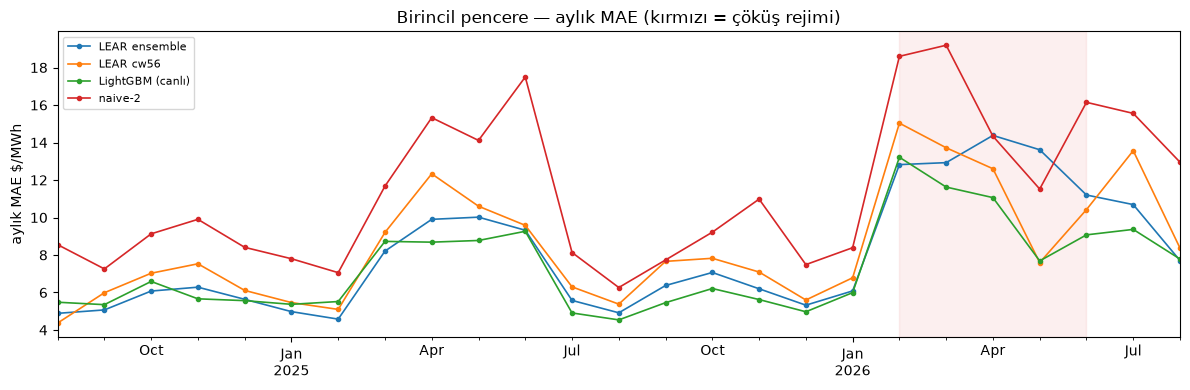

In [10]:
# aylık MAE — ensemble vs LightGBM vs en iyi tek pencere (birincil)
keep = _prep(prim_models, prim_days)
mo = pd.Index(keep).to_period('M')
fig, ax = plt.subplots(figsize=(12, 4))
for name in ['LEAR ensemble', 'LEAR cw56', 'LightGBM (canlı)', 'naive-2']:
    d = lear.get(name, prim_models[name])
    e = np.abs(y.reindex(keep).to_numpy() - d.reindex(keep).to_numpy()).mean(1)
    pd.Series(e, index=keep).groupby(mo).mean().plot(ax=ax, marker='o', ms=3, lw=1.2, label=name)
ax.axvspan(pd.Period('2026-02','M').to_timestamp(), pd.Period('2026-06','M').to_timestamp(), color='tab:red', alpha=.07)
ax.set(ylabel='aylık MAE $/MWh', xlabel='', title='Birincil pencere — aylık MAE (kırmızı = çöküş rejimi)')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


## 3. Sonuç

> **Güncelleme (Faz C.5.3', 31 Ağu):** LightGBM ailesine **çok-pencereli ensemble** eklendi
> (son 90g / 150g / tüm-geçmiş, P50 ortalaması). WF koşuları `--proxy-from` YOK (kaskad bug'ı
> düzeltildikten sonra), sızıntısız. Framework doğrulaması: tek-model WF ≈ canlı DB.
> Detay: `08_collapse_fix_experiments.ipynb`.

### Uzun pencere (3 yıl, 1096 gün)

| Model | MAE | rMAE(n2) | rMAE(n3) |
|---|---|---|---|
| **LightGBM ensemble (90/150/tüm)** | **$7.30** | **0.630** | **0.720** |
| LightGBM WF (tek, canlı politika) | $7.44 | 0.642 | 0.733 |
| LEAR ensemble (4 pencere ort.) | $8.00 | 0.690 | 0.789 |
| LEAR cw56 / cw84 / cw1456 / cw1092 | $8.72 / $8.79 / $8.84 / $8.98 | 0.75–0.78 | |
| naive-3 / naive-2 | $10.14 / $11.59 | | |

**1. LightGBM ensemble en iyi** — LEAR ensemble'ı **DM p = 2.9×10⁻¹³**, tek-model LightGBM'i
**DM p = 6.5×10⁻⁵** ile geçiyor. LEAR tarafında: pencere sıralaması kısa < uzun (`cw56` en iyi,
3 yıllık `cw1092` en kötü); Lago'nun '4 pencere birlikte' savı ensemble için doğru ama tek
pencere seçilecekse TR'de kısa kazanıyor. 4-yıl (`cw1456`) katkısı zayıf.

### Birincil pencere (728 gün, 725 temiz)

| Model | MAE | rMAE(n2) | rMAE(n3) |
|---|---|---|---|
| **LightGBM ensemble (90/150/tüm)** | **$7.15** | **0.626** | **0.735** |
| LightGBM (canlı = lag0_v2) | $7.35 | 0.644 | 0.756 |
| LEAR ensemble | $8.08 | 0.709 | 0.832 |
| LEAR cw56 / cw1456 / cw1092 | $8.60 / $9.15 / $9.35 | | |

**2. LightGBM ensemble canlı modeli DM p = 4.4×10⁻⁵, LEAR ensemble'ı p = 1.4×10⁻¹⁴ ile geçiyor.**
Canlı LightGBM zaten LEAR ensemble'ı p = 1.9×10⁻⁹ ile geçiyordu — ensemble onun da üstüne çıkıyor.

### Rejim katmanları (birincil pencere)

| Model | normal (520g) | **çöküş** (147g) | toparlanma (58g) |
|---|---|---|---|
| **LightGBM ensemble** | 6.32 | **9.65** | **8.20** |
| LightGBM (canlı) | **6.30** | 10.54 | 8.63 |
| LEAR ensemble | 6.56 | 12.98 | 9.30 |
| LEAR cw56 (kısa) | 7.38 | 11.90 | 11.15 |
| LEAR cw1092 / cw1456 | 7.21 / 7.11 | 17.13 / 16.40 | 8.85 / 8.98 |
| naive-2 | 9.78 | 16.00 | 14.34 |

**3. LightGBM ensemble çöküş ($10.54 → $9.65) ve toparlanmayı ($8.63 → $8.20) belirgin
iyileştiriyor, normalde nötr** (6.30 → 6.32). Tek-model LightGBM zaten 3 katmanın hepsinde
LEAR'dan iyiydi; ensemble onu rejim geçişlerinde (çöküş/toparlanma) daha da öne çıkarıyor.
**`03`'teki 'LEAR çöküşte rekabetçi' bulgusu kanonik protokolde hâlâ geçersiz.**

**4. Çöküşte kısa LEAR penceresi uzunu eziyor** (`cw56` $11.90 vs `cw1092` $17.13) — 3-4 yıllık
pencere çöküş rejimini normal örnekler içinde seyreltiyor. Aynı prensip LightGBM ensemble'ın
kısa üyelerinin (90g/150g) çöküşü nasıl düzelttiğini açıklıyor (`08 §3-4`).

### Bir cümle

**LightGBM çok-pencereli ensemble** (canlı `lag0_v2` konfigü, son 90g/150g/tüm-geçmiş P50 ortalaması)
hem genel (uzun $7.30, birincil $7.15) hem her rejim katmanında hem canlı tek-model LightGBM'i
hem de makalenin kendi açık-erişim benchmark'ını (LEAR ensemble, gerçek epftoolbox) istatistiksel
olarak anlamlı geçiyor; kazancın büyük kısmı çöküş/toparlanma rejimlerinden geliyor, normalde nötr.
